# COURSE: A deep understanding of deep learning
## SECTION: ANNs
### LECTURE: ANN for regression
#### TEACHER: Mike X Cohen, sincxpress.com
##### COURSE URL: udemy.com/course/deeplearning_x/?couponCode=202401

In [112]:
# import libraries
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

In [113]:
def create_data(m, N=50):
    """Creates x and y data with slope m and Gaussian noise."""
    x = torch.randn(N, 1)
    y = m * x + torch.randn(N, 1) / 2
    return x, y


In [114]:
def build_and_train(x, y, numepochs=500, lr=0.05):
    """Builds, trains the ANN regression model and returns predictions and losses."""
    
    # Build model (no ReLU for regression!)
    model = nn.Sequential(
        nn.Linear(1, 1),
        nn.ReLU(),
        nn.Linear(1, 1)
    )
    
    lossfun  = nn.MSELoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    
    losses = torch.zeros(numepochs)
    
    for epochi in range(numepochs):
        yHat = model(x)
        loss = lossfun(yHat, y)
        losses[epochi] = loss.item()
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    # Final predictions 
    predictions = model(x)
    
    return predictions.detach(), losses


In [115]:
# Parameters
slopes     = np.linspace(-2, 2, 21)  # 21 steps from -2 to +2
n_runs     = 50                       # repeat 50 times

# Storage
all_losses       = np.zeros((len(slopes), n_runs))
all_correlations = np.zeros((len(slopes), n_runs))

for si, m in enumerate(slopes):
    for run in range(n_runs):
        x, y = create_data(m)
        predictions, losses = build_and_train(x, y)
        
        # Final loss
        all_losses[si, run] = losses[-1].item()
        
        # Correlation between y and ŷ
        y_np    = y.numpy().squeeze()
        yHat_np = predictions.numpy().squeeze()
        
        if y_np.std() > 0 and yHat_np.std() > 0:
            corr = np.corrcoef(y_np, yHat_np)[0, 1]
        else:
            corr = 0.0
        all_correlations[si, run] = corr

print("Experiment done!")


Experiment done!


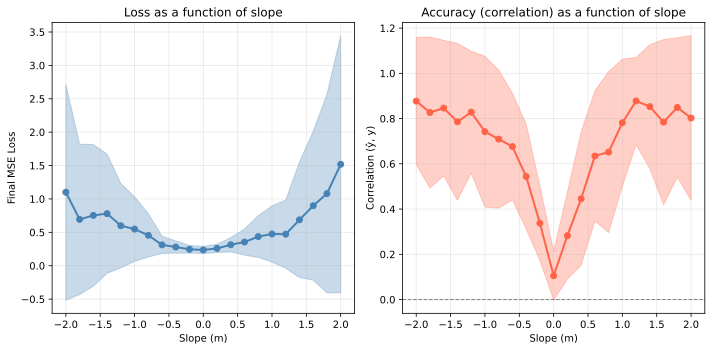

In [118]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, data, title, ylabel, color in zip(
    axes,
    [all_losses, all_correlations],
    ['Loss as a function of slope', 'Accuracy (correlation) as a function of slope'],
    ['Final MSE Loss', 'Correlation (ŷ, y)'],
    ['steelblue', 'tomato']
):
    m  = np.nanmean(data, axis=1)
    sd = np.nanstd(data, axis=1)
    ax.plot(slopes, m, 'o-', color=color, linewidth=2)
    ax.fill_between(slopes, m - sd, m + sd, alpha=0.3, color=color)
    ax.set(xlabel='Slope (m)', ylabel=ylabel, title=title)
    ax.grid(True, alpha=0.3)
axes[1].axhline(0, color='gray', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()


In [111]:
x_test, y_test = create_data(1.0)
preds, losses = build_and_train(x_test, y_test)
print("Losses (last 5):", losses[-5:])
print("Predictions (first 5):", preds[:5])
print("Any NaN in losses?", torch.isnan(losses).any())


Losses (last 5): tensor([0.9389, 0.9389, 0.9389, 0.9389, 0.9389])
Predictions (first 5): tensor([[-0.1027],
        [-0.1027],
        [-0.1027],
        [-0.1027],
        [-0.1027]])
Any NaN in losses? tensor(False)
